In [6]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [7]:
df = pd.read_csv("HouseVSPrice.csv")#Read the CSV FILE !!

In [8]:
df.head()

,House_Size_sqft,House_Price_Lakhs
0,800,30.8
1,805,31.3
2,810,31.8
3,815,32.3
4,820,32.8


In [9]:
df.isnull().sum()#Checking NULL

House_Size_sqft      0
House_Price_Lakhs    0
dtype: int64

In [10]:
df.dropna(inplace = True) #Exact match

In [11]:
df.isnull().sum()

House_Size_sqft      0
House_Price_Lakhs    0
dtype: int64

In [12]:
df.shape

(500, 2)

In [13]:
x=df[['House_Size_sqft']]#it will be an (500,1) 500 rows and 1 column not a Serial data!!
y=df['House_Price_Lakhs']#it is  Serial (500,)



In [14]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train, y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)
#X_TEST=[set of 20 % of the X ] 
#X_TRAIN=[set of 80% of the X]
#Y_TEST=[set of 20% of the Y ] OUTPUT !! 
#Y_TRAIN=[set of 80% of the Y] Output WE train it !! 

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lr = LinearRegression()

In [17]:
lr.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.04]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['House_Size_sqft']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1105
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [23]:
y_pred = lr.predict(X_test)

In [24]:
y_pred

array([104.20099506,  46.66155335, 106.79826153,  63.04431106,
        52.85503493, 110.79405609, 107.39763072,  56.85082949,
        45.66260471, 121.98228087,  33.87501075,  70.83611046,
       113.19153283,  48.85924036, 106.19889235, 109.59531772,
       130.97281864,  38.07059504,  95.2104573 , 113.59111229,
       129.97387   , 130.17365973,  88.01802708, 103.20204642,
        47.26092254, 124.17996788, 131.37239809,  74.23253584,
        52.25566574,  98.8066724 , 126.97702407,  99.20625186,
       119.98438359,  66.64052617,  32.47648266,  98.60688268,
       113.79090202,  46.06218417,  73.83295638,  44.66365607,
       108.79615881,  50.65734792, 128.97492136,  69.03800291,
        38.66996423,  47.46071227,  32.0769032 ,  34.27459021,
       114.98964039,  36.47227722,  46.46176363,  68.43863372,
        58.24935759, 113.99069174,  70.63632073,  43.06533825,
        61.64578297,  35.67311831,  72.83400774,  47.660502  ,
       130.77302891,  84.42181198,  96.60898539, 128.57

In [23]:
X_test

,House_Size_sqft
361,2605
73,1165
374,2670
155,1575
104,1320
...,...
347,2535
86,1230
75,1175
438,2990


In [24]:
y_test

361    103.3
73      45.7
374    107.1
155     62.4
104     53.1
       ...  
347    101.7
86      49.5
75      46.7
438    120.2
15      35.6
Name: House_Price_Lakhs, Length: 100, dtype: float64

In [25]:
from sklearn.metrics import r2_score

In [26]:
r2 = r2_score(y_test ,y_pred)

In [27]:
r2

0.9993935837524304

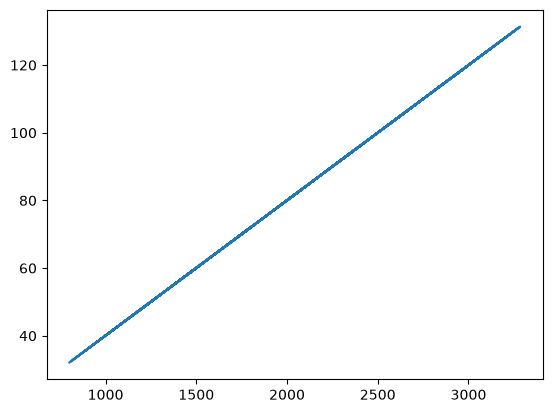

In [29]:
plt.plot(X_test,y_pred)